In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [83]:
df = pd.read_csv('/home/server/Projects/data/AKI/aki_data_normalized.csv')

# Smote with resampling ONLY on training data, not on test data.
# This is to preserve the real-world test distribution.

# Step 1: Split BEFORE upsampling (preserves real-world test distribution)
df = df[[col for col in df.columns if col != "aki_boolean"] + ["aki_boolean"]]
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["aki_boolean"])

In [84]:
y_binary_train = df_train.iloc[:, -1]
X_train = df_train.iloc[:, :-1]

In [85]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_binary_train)

In [86]:
df = pd.concat([X_res, y_res], axis=1)
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [87]:
y_test = df_test.iloc[:, -3].values
y_binary_test = df_test.iloc[:, -2].values
y_positive_test = df_test.iloc[:, -1].values
X_test = df_test.iloc[:, :-3].values

In [88]:
df

,age,sex,height,weight,asa,emop,BSA,BMI,booking_case_length,num_card_events,...,preop_ast_isna,preop_crp_isna,preop_hb_isna,preop_hct_isna,preop_seg_isna,aki_isna,op_len_isna,aki,aki_positive,aki_boolean
0,1.794550,False,-0.862166,-1.094125,2.000000,0.000000,-1.131489,-0.797282,-0.602267,0.091291,...,False,False,False,False,False,False,False,0.050000,0.050000,False
1,1.459807,False,-0.862166,-0.664414,2.000000,1.000000,-0.746848,-0.220088,-0.176699,-0.220850,...,False,False,False,False,False,False,False,0.140000,0.140000,False
2,1.125065,True,0.264279,-0.234704,2.000000,0.000000,-0.105204,-0.457008,-0.640955,-0.220850,...,False,False,False,False,False,False,False,0.000000,0.000000,False
3,1.125065,True,0.264279,-0.234704,2.000000,0.000000,-0.105204,-0.457008,1.641636,0.403433,...,False,False,False,False,False,False,False,-0.210000,0.000000,False
4,-2.222364,True,1.390724,0.195006,1.000000,0.000000,0.535284,-0.682786,-0.911771,-0.220850,...,False,False,False,False,False,False,False,0.110000,0.110000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76763,0.761296,False,-1.425388,-1.281034,2.521678,0.000000,-1.453722,-0.674149,-0.358397,0.688508,...,False,True,False,False,False,False,False,0.493930,0.493930,True
76764,-0.298070,True,1.214516,-0.234704,1.687144,0.000000,0.119437,-1.034121,-0.771720,-0.220850,...,False,False,False,False,False,False,False,0.464972,0.464972,True
76765,0.463091,True,0.264279,-1.065196,2.000000,0.000000,-0.855674,-1.441420,2.114574,-0.068282,...,False,False,False,False,False,False,False,0.330996,0.330996,True
76766,0.790322,True,0.060123,-0.625018,2.000000,0.000000,-0.498188,-0.804913,0.354128,-0.220850,...,False,False,False,False,False,False,False,0.437165,0.437165,True


In [89]:
y_train = df.iloc[:, -3].values
y_binary_train = df.iloc[:, -1].values
y_positive_train = df.iloc[:, -2].values
X_train = df.iloc[:, :-3].values

In [90]:
np.savez_compressed(
    "/home/server/Projects/data/AKI/preop_trainable/smoted.npz",
    X_train_smote=X_train,
    y_train_smote=y_train,
    y_binary_train_smote=y_binary_train,
    y_positive_train_smote=y_positive_train,
)

Counter({False: 38384, True: 2686})
Counter({False: 38384, True: 5932})
Counter({False: 38384, True: 9177})
Counter({False: 38384, True: 12422})
Counter({False: 38384, True: 15667})
Counter({False: 38384, True: 18912})
Counter({False: 38384, True: 22158})
Counter({False: 38384, True: 25403})
Counter({False: 38384, True: 28648})
Counter({False: 38384, True: 31893})
Counter({False: 38384, True: 35138})
Counter({False: 38384, True: 38384})


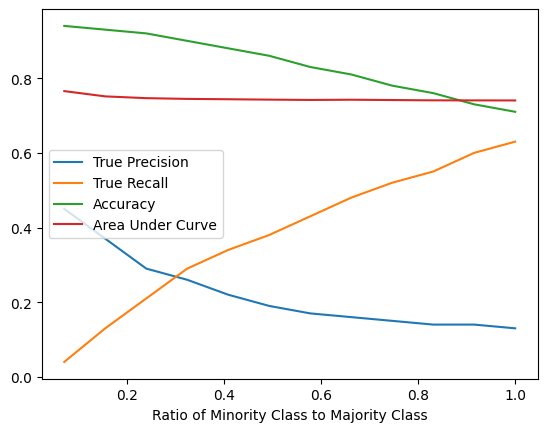

In [69]:
#iterating through splits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

ratios = np.linspace(0.07, 1, 12)
true_precisions = []
true_recalls = []
accs = []
aucs = []

for ratio in ratios:
    df = pd.read_csv('/home/server/Projects/data/AKI/aki_data_normalized.csv')
    df = df[[col for col in df.columns if col != "aki_boolean"] + ["aki_boolean"]]
    df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["aki_boolean"])
    y_binary_train = df_train.iloc[:, -1]
    X_train = df_train.iloc[:, :-1]
    smote = SMOTE(random_state=42, sampling_strategy=ratio) #changed from auto(1) to ratio
    X_res, y_res = smote.fit_resample(X_train, y_binary_train)
    print(Counter(y_res))
    df = pd.concat([X_res, y_res], axis=1)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    y_test = df_test.iloc[:, -3].values
    y_binary_test = df_test.iloc[:, -2].values
    y_positive_test = df_test.iloc[:, -1].values
    X_test = df_test.iloc[:, :-3].values
    y_train = df.iloc[:, -3].values
    y_binary_train_smote = df.iloc[:, -1].values #added _smote
    y_positive_train = df.iloc[:, -2].values
    X_train_smote = df.iloc[:, :-3].values      #added _smote
    with np.load('/home/server/Projects/data/AKI/preop_trainable/normalized.npz', allow_pickle=True) as data:
        X_train=data["X_train_normalized"]
        X_test=data["X_test_normalized"]
        y_train=data["y_train_normalized"]
        y_test=data["y_test_normalized"]
        y_binary_train=data["y_binary_train_normalized"]
        y_binary_test=data["y_binary_test_normalized"]
        y_positive_train=data["y_positive_train_normalized"]
        y_positive_test=data["y_positive_test_normalized"]


    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_smote, y_binary_train_smote)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_binary_test, y_pred)
    # print(f'Accuracy: {accuracy:.2f}')

    cm = confusion_matrix(y_binary_test, y_pred)
    # print('Confusion Matrix:')
    # print(cm)

    report = classification_report(y_binary_test, y_pred)
    # print('Classification Report:')
    # print(report)

    # Get predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # print(f'ROC curve (area = {roc_auc:.2f})')

    tokens = report.split()
    true_precisions.append(float(tokens[10]))
    true_recalls.append(float(tokens[11]))
    accs.append(float(tokens[15]))
    aucs.append(roc_auc)
plt.plot(ratios, true_precisions, label = "True Precision")
plt.plot(ratios, true_recalls, label = "True Recall")
plt.plot(ratios, accs, label = "Accuracy")
plt.plot(ratios, aucs, label = "Area Under Curve")
plt.xlabel("Ratio of Minority Class to Majority Class")
plt.legend()
plt.show()

In [1]:
plt.plot(ratios, true_precisions, label = "True Precision", color='b')
plt.plot(ratios, true_recalls, label = "True Recall", color='orange')
plt.plot(ratios, accs, label = "Accuracy", color='g')
plt.plot(ratios, aucs, label = "Area Under Curve", color='r')
plt.xlabel("Ratio of Minority Class to Majority Class")
plt.legend()

#NONSMOTED, NORMALIZED
plt.scatter(1, 0.15, color='b')
plt.scatter(1, 0.66, color='orange')
plt.scatter(1, 0.73, color='g')
plt.scatter(1, 0.77, color='r')

#NIDHIRS NUMBERS
b = 1
plt.scatter(b, 0.13, color='b')
plt.scatter(b, 0.63, color='orange')
plt.scatter(b, 0.71, color='g')
plt.scatter(b, 0.74, color='r')

plt.show()
print("Individual points are color coded to category and are the values from Tuesday (First pass at Smote)")

NameError: name 'plt' is not defined

In [70]:
df = pd.read_csv('/home/server/Projects/data/AKI/aki_data_normalized.csv')
df = df[[col for col in df.columns if col != "aki_boolean"] + ["aki_boolean"]]
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["aki_boolean"])
y_binary_train = df_train.iloc[:, -1]
X_train = df_train.iloc[:, :-1]
# smote = SMOTE(random_state=42, sampling_strategy=ratio) #changed from auto(1) to ratio
# X_res, y_res = smote.fit_resample(X_train, y_binary_train)
X_res, y_res = X_train, y_binary_train #replaced prev two lines
print(Counter(y_res))
df = pd.concat([X_res, y_res], axis=1)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
y_test = df_test.iloc[:, -3].values
y_binary_test = df_test.iloc[:, -2].values
y_positive_test = df_test.iloc[:, -1].values
X_test = df_test.iloc[:, :-3].values
y_train = df.iloc[:, -3].values
y_binary_train_smote = df.iloc[:, -1].values #added _smote
y_positive_train = df.iloc[:, -2].values
X_train_smote = df.iloc[:, :-3].values      #added _smote
with np.load('/home/server/Projects/data/AKI/preop_trainable/normalized.npz', allow_pickle=True) as data:
    X_train=data["X_train_normalized"]
    X_test=data["X_test_normalized"]
    y_train=data["y_train_normalized"]
    y_test=data["y_test_normalized"]
    y_binary_train=data["y_binary_train_normalized"]
    y_binary_test=data["y_binary_test_normalized"]
    y_positive_train=data["y_positive_train_normalized"]
    y_positive_test=data["y_positive_test_normalized"]


model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_binary_train_smote)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_binary_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred)
print('Classification Report:')
print(report)

# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f'ROC curve (area = {roc_auc:.2f})')

# tokens = report.split()
# true_precisions.append(float(tokens[10]))
# true_recalls.append(float(tokens[11]))
# accs.append(float(tokens[15]))
# aucs.append(roc_auc)

Counter({False: 38384, True: 2635})
Accuracy: 0.94
Confusion Matrix:
[[9566   30]
 [ 633   26]]
Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      9596
        True       0.46      0.04      0.07       659

    accuracy                           0.94     10255
   macro avg       0.70      0.52      0.52     10255
weighted avg       0.91      0.94      0.91     10255

ROC curve (area = 0.77)


The minimum number of True's (minority class) is 2635/(38384 + 2635), that's the base number that come in the data. I made a simple for loop which repeats the smote code several times with different values for the ratio between minority class and majority class. This loop is lower bounded around 0.06-0.07 bc that's 2635, indicating the case where very few synthesized data should be added. On the 1.0 end, which is what nidhir's code emulates, we have 50% minority, 50% majority. My 1.0 end's performance numbers align with nidhir's, indicating that my code correctly mimics his dataflow. We should expect the 0.06-0.07 end to mimic our non-smoted-data precision/recall values, but the above cell has bad values. I think there's something wrong with alg, not smote. 

TLDR; previous testing said smote < nonsmote, but trends indicate the opposite (false negs skyrocket). Also, smoting with no added cases does not replicate non smote case.